In [38]:
import os
import re
import numpy as np
import pandas as pd
from scipy.ndimage import binary_closing

mus = ['TA', 'MG', 'VL', 'BF']
TARGET_ROWS = 30000

folder_001 = r"C:\Users\masay\Documents\EMG_OpenSource\001\merged_data_mini"
folder_003 = r"C:\Users\masay\Documents\EMG_OpenSource\003\merged_data"
folder_006 = r"C:\Users\masay\Documents\EMG_OpenSource\006\Final_Processed_EMG"

from scipy.signal import butter, lfilter, lfilter_zi

def emg_lfilter(
    emg,
    fs=1000,
    lowcut=20,
    highcut=450,
    order=2
):
    """
    生EMG用 バンドパス Butterworth（因果・オンライン対応）
    - filtfilt 不使用
    - 初期過渡応答を抑制（lfilter_zi 使用）
    - 学習・オンライン制御で同一処理
    
    Parameters
    ----------
    emg : array-like
        生EMG信号（1次元）
    fs : float
        サンプリング周波数 [Hz]
    lowcut : float
        下限周波数 [Hz]
    highcut : float
        上限周波数 [Hz]
    order : int
        フィルタ次数（2推奨）
    """
    emg = np.asarray(emg)

    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq

    # Butterworth バンドパス（因果）
    b, a = butter(order, [low, high], btype='band')

    # 定常状態を仮定した初期条件
    zi = lfilter_zi(b, a) * emg[0]

    # フィルタ適用
    emg_filt, _ = lfilter(b, a, emg, zi=zi)

    return emg_filt



def emg_envelope_exp_rms(emg, alpha=0.05):
    """
    指数移動RMSによるEMG包絡（オンライン対応）
    """
    
    env = np.zeros_like(emg)

    for i in range(len(emg)):
        if i == 0:
            env[i] = abs(emg[i])
        else:
            env[i] = np.sqrt(
                (1 - alpha) * env[i-1]**2 + alpha * emg[i]**2
            )
    return env



# =========================
# utils
# =========================
def zscore_trial(x, eps=1e-8):
    """
    試行ごと標準化
    x: [T, C]
    """
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)

    return (x - mean) / (std + eps)


def process_emg(df):
    """
    出力:
    [T, 8]
      - 前半4ch: フィルタ済み生波形（標準化）
      - 後半4ch: envelope/RMS（標準化）
    """

    raw_processed = []
    rms_processed = []

    for n in mus:

        # -----------------
        # フィルタ済み生波形
        # -----------------
        raw = emg_lfilter(df[n].values)

        # -----------------
        # RMS/envelope
        # -----------------
        rms = emg_envelope_exp_rms(raw, alpha=0.03)

        raw_processed.append(raw)
        rms_processed.append(rms)

    # [T, 4]
    raw_processed = np.array(raw_processed).T
    rms_processed = np.array(rms_processed).T

    # -----------------
    # 試行ごと標準化
    # -----------------
    raw_processed = zscore_trial(raw_processed)
    rms_processed = zscore_trial(rms_processed)

    # -----------------
    # concat
    # -----------------
    X = np.concatenate([raw_processed, rms_processed], axis=1)

    return X


def extract_subject_001(filename):
    m = re.search(r"subject(\d+)", filename)
    return int(m.group(1))


def extract_subject_006(filename):
    m = re.search(r"P(\d{4})", filename)
    return int(m.group(1))


# =========================
# split rule
# =========================
def is_train_001(s): return 1 <= s <= 14
def is_val_001(s):   return 15 <= s <= 19

def is_train_003(s): return 1 <= s <= 109
def is_val_003(s):   return 110 <= s <= 135

def is_train_006(s): return 1 <= s <= 25
def is_val_006(s):   return 25 <= s <= 30


# =========================
# storage
# =========================
train_data = {}
val_data = {}
skipped = []


# =========================
# 001 processing
# =========================
files_001 = os.listdir(folder_001)

for f in files_001:

    if not f.endswith(".csv"):
        continue

    path = os.path.join(folder_001, f)
    df = pd.read_csv(path)

    if len(df) != TARGET_ROWS:
        skipped.append(("001", f, len(df)))
        continue

    subj = extract_subject_001(f)

    stance = df["Stance"].values
    stance = binary_closing(
        stance,
        structure=np.ones(5)
    ).astype(int)

    X = process_emg(df)
    y = stance

    if is_train_001(subj):
        train_data.setdefault(("001", subj), []).append((X, y))

    if is_val_001(subj):
        val_data.setdefault(("001", subj), []).append((X, y))


# =========================
# 003 processing
# =========================
for i in range(1, 136):

    for j in range(1, 3):

        path = fr"{folder_003}\P{i:04d}_{j:02d}_merged.csv"

        if not os.path.exists(path):
            continue

        df = pd.read_csv(path)

        if len(df) != TARGET_ROWS:
            skipped.append(("003", os.path.basename(path), len(df)))
            continue

        stance = df["Stance"].values
        stance = binary_closing(
            stance,
            structure=np.ones(5)
        ).astype(int)

        X = process_emg(df)
        y = stance

        if is_train_003(i):
            train_data.setdefault(("003", i), []).append((X, y))

        if is_val_003(i):
            val_data.setdefault(("003", i), []).append((X, y))


# =========================
# 006 processing
# =========================
files_006 = os.listdir(folder_006)

for f in files_006:

    if not f.endswith(".csv"):
        continue

    path = os.path.join(folder_006, f)
    df = pd.read_csv(path)

    if len(df) != TARGET_ROWS:
        skipped.append(("006", f, len(df)))
        continue

    subj = extract_subject_006(f)

    stance = df["Stance"].values
    stance = binary_closing(
        stance,
        structure=np.ones(5)
    ).astype(int)

    X = process_emg(df)
    y = stance

    if is_train_006(subj):
        train_data.setdefault(("006", subj), []).append((X, y))

    if is_val_006(subj):
        val_data.setdefault(("006", subj), []).append((X, y))


# =========================
# pack function
# =========================
def pack(data_dict):

    X_all = []
    y_all = []

    for key, data in data_dict.items():

        X = np.stack([d[0] for d in data])
        y = np.stack([d[1] for d in data])

        X_all.append(X)
        y_all.append(y)

    return (
        np.concatenate(X_all),
        np.concatenate(y_all)
    )


X_train, y_train = pack(train_data)
X_val, y_val = pack(val_data)


print("TRAIN:", X_train.shape)
print("VAL:", X_val.shape)

# ch確認
print("channels:", X_train.shape[-1])

# =========================
# leakage check
# =========================
print("\ntrain subjects:", len(train_data))
print("val subjects:", len(val_data))

if skipped:
    print("\nskipped:", len(skipped))

TRAIN: (405, 30000, 8)
VAL: (106, 30000, 8)
channels: 8

train subjects: 148
val subjects: 37

skipped: 2


In [39]:
np.savez(
    "opensource_emg_dataset_plus_rawdata.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

In [40]:
data = np.load("opensource_emg_dataset_plus_rawdata.npz")

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(405, 30000, 8)
(405, 30000)
(106, 30000, 8)
(106, 30000)


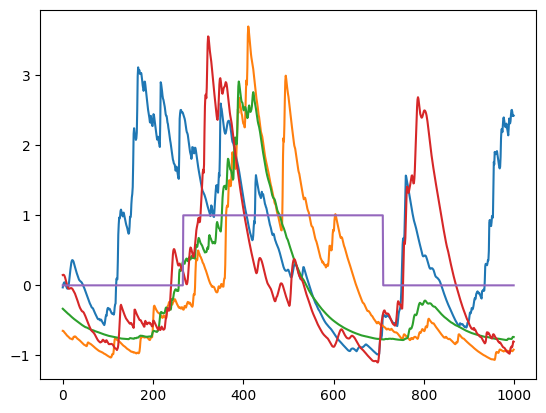

In [44]:
sub=1
X=X_train[i]
y=y_train[i]

X=X[:,4:8]
plt.plot(X[5000:6000])
plt.plot(y[5000:6000])